Đang xử lý BĐS: street_house.csv...


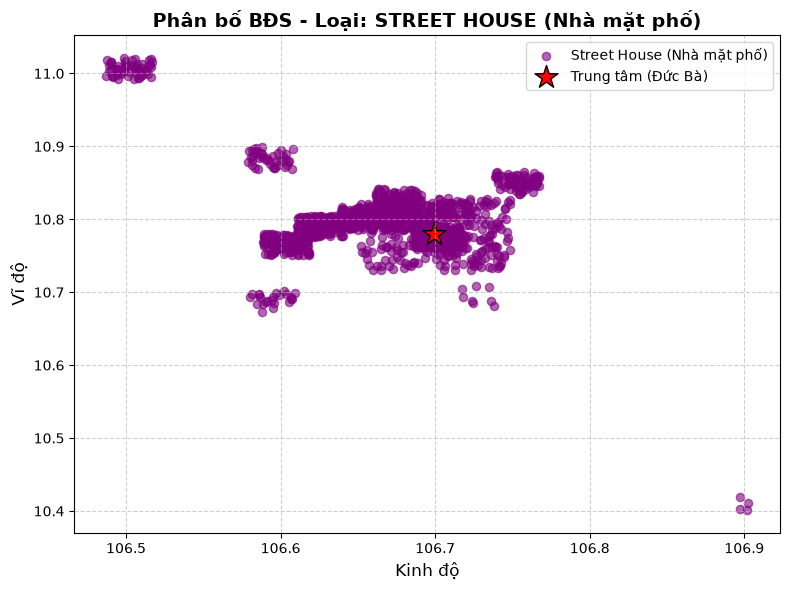

✅ Hoàn thành! Đã lưu file sạch tại: ../../data/process/properties/cleaned_street_house.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from geopy.distance import geodesic

# 1. THIẾT LẬP ĐƯỜNG DẪN VÀ TÊN FILE
RAW_PROPERTIES_DIR = '../../data/raw/properties/'
PROCESS_PROPERTIES_DIR = '../../data/process/properties/'
os.makedirs(PROCESS_PROPERTIES_DIR, exist_ok=True)

# File mục tiêu là Nhà mặt phố
TARGET_FILE = 'street_house.csv' 

# Tọa độ Nhà thờ Đức Bà (Trung tâm)
ndc_coords = (10.779785, 106.699028) 

# Từ điển Map tọa độ siêu tốc
hcm_districts = {
    'quận 1': (10.7756, 106.7019), 'q1': (10.7756, 106.7019), 'q.1': (10.7756, 106.7019),
    'quận 2': (10.7872, 106.7495), 'quận 3': (10.7843, 106.6839), 'quận 4': (10.7578, 106.7012),
    'quận 5': (10.7540, 106.6633), 'quận 6': (10.7480, 106.6352), 'quận 7': (10.7324, 106.7301),
    'quận 8': (10.7224, 106.6279), 'quận 9': (10.8428, 106.8286), 'quận 10': (10.7743, 106.6669),
    'quận 11': (10.7628, 106.6444), 'quận 12': (10.8671, 106.6413), 'bình thạnh': (10.8105, 106.7091), 
    'gò vấp': (10.8271, 106.6764), 'phú nhuận': (10.7991, 106.6788), 'tân bình': (10.8014, 106.6525), 
    'tân phú': (10.7904, 106.6254), 'bình tân': (10.7652, 106.6038), 'thủ đức': (10.8494, 106.7537), 
    'hóc môn': (10.8841, 106.5940), 'củ chi': (11.0066, 106.5022), 'nhà bè': (10.6952, 106.7317), 
    'bình chánh': (10.6873, 106.5946), 'cần giờ': (10.4079, 106.9069)
}

def get_coordinates_smart(addr):
    addr_lower = str(addr).lower()
    for key, coords in hcm_districts.items():
        if key in addr_lower:
            return pd.Series([coords[0] + random.uniform(-0.015, 0.015), coords[1] + random.uniform(-0.015, 0.015)])
    lat_jitter = ndc_coords[0] + random.uniform(-0.05, 0.05)
    lon_jitter = ndc_coords[1] + random.uniform(-0.05, 0.05)
    return pd.Series([lat_jitter, lon_jitter])

def calc_dist(row):
    if pd.notna(row['latitude']) and pd.notna(row['longitude']):
        return geodesic((row['latitude'], row['longitude']), ndc_coords).kilometers
    return None

print(f"Đang xử lý BĐS: {TARGET_FILE}...")

# 2. ĐỌC DỮ LIỆU
file_path = os.path.join(RAW_PROPERTIES_DIR, TARGET_FILE)
df = pd.read_csv(file_path)
df.columns = [c.strip().lower() for c in df.columns]

# 3. ĐỔI TÊN CỘT SANG TIẾNG ANH
col_mapping = {}
for col in df.columns:
    if ('dia_chi' in col or 'địa chỉ' in col) and 'chi tiết' not in col and 'chi_tiet' not in col:
        col_mapping[col] = 'address'
    elif 'tong_gia' in col or 'tổng giá' in col or 'tổng tiền' in col:
        col_mapping[col] = 'total_price'
    elif 'tien_m2' in col or 'tiền_m2' in col or 'giá/m2' in col:
        col_mapping[col] = 'price_per_m2'
        
df = df.rename(columns=col_mapping)

# 4. BỎ TRƯỜNG DỮ LIỆU NONE > 2/3
threshold = len(df) / 3
df = df.dropna(axis=1, thresh=threshold)

# 5. CHỈ GIỮ LẠI BĐS Ở TP.HCM
df = df.dropna(subset=['address'])
df = df[df['address'].astype(str).str.contains("TP.HCM|Hồ Chí Minh|HCM", case=False, na=False)].copy()

# 6. THÊM FEATURE DIỆN TÍCH
if 'total_price' in df.columns and 'price_per_m2' in df.columns:
    df['total_price'] = pd.to_numeric(df['total_price'], errors='coerce')
    df['price_per_m2'] = pd.to_numeric(df['price_per_m2'], errors='coerce')
    df['area_calculated'] = df['total_price'] / df['price_per_m2']

# 7. THÊM TỌA ĐỘ VÀ KHOẢNG CÁCH
df[['latitude', 'longitude']] = df['address'].apply(get_coordinates_smart)
df['center_distance_km'] = df.apply(calc_dist, axis=1)

# 8. LOẠI BỎ HOÀN TOÀN CỘT KHÔNG CẦN THIẾT
cols_to_keep = ['address', 'total_price', 'price_per_m2', 'area_calculated', 'latitude', 'longitude', 'center_distance_km']
for extra_col in ['số phòng ngủ', 'số phòng tắm', 'diện tích sử dụng']:
    if extra_col in df.columns:
        cols_to_keep.append(extra_col)
        
cols_to_keep = [col for col in cols_to_keep if col in df.columns]
df = df[cols_to_keep]

# 9. TRỰC QUAN HÓA (VẼ BIỂU ĐỒ)
plt.figure(figsize=(8, 6))
# Đổi màu biểu đồ thành màu tím (purple)
plt.scatter(df['longitude'], df['latitude'], alpha=0.6, color='purple', s=35, label='Street House (Nhà mặt phố)')
plt.scatter([ndc_coords[1]], [ndc_coords[0]], color='red', marker='*', s=300, edgecolor='black', label='Trung tâm (Đức Bà)')
plt.title('Phân bố BĐS - Loại: STREET HOUSE (Nhà mặt phố)', fontsize=14, fontweight='bold')
plt.xlabel('Kinh độ', fontsize=12)
plt.ylabel('Vĩ độ', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 10. LƯU LẠI FILE
output_path = os.path.join(PROCESS_PROPERTIES_DIR, f'cleaned_{TARGET_FILE}')
df.to_csv(output_path, index=False)
print(f"✅ Hoàn thành! Đã lưu file sạch tại: {output_path}")